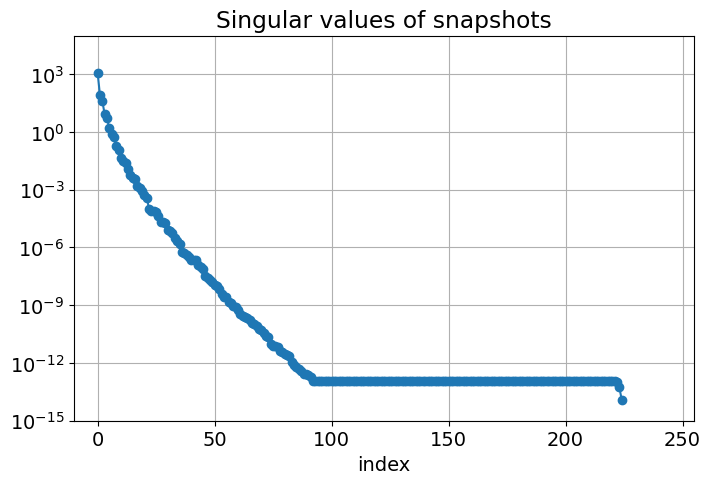

In [ ]:
import numpy as np
import time
from scipy.linalg import qr
import matplotlib.pyplot as plt
import sympy as sp

# make text in plots twice as large as the default
plt.rcParams.update({"font.size": 14})

# Parameters
nx = 100  # grid points in x
ny = 100  # grid points in y
n = nx * ny  # dimension of the full system
ell = 10  # DEIM reduced dimension
num_mu1_samples = 15
num_mu2_samples = 15
num_snapshots = num_mu1_samples * num_mu2_samples
num_runs = num_snapshots  # Number of runs for averaging timings

x = np.linspace(0.1, 0.9, nx)
y = np.linspace(0.1, 0.9, ny)
xx, yy = np.meshgrid(x, y)


def get_2d_indices(indices):
    """Map flat indices to 2D row and column indices."""
    rows = indices // ny
    cols = indices % ny
    return rows, cols


# Nonlinear function (vectorized)
def f(mu, indices=None):
    mu1, mu2 = mu
    if indices is None:
        f1 = 1 / np.sqrt(
            (xx - mu1) ** 2 + (yy - mu2) ** 2 + 0.1**2
        )  # 10 * np.sin(mu1 * xx) * np.cos(mu2 * yy)
        return f1.flatten()
    else:
        # Evaluate only at specific indices
        func_vals = np.zeros(len(indices))
        rows, cols = get_2d_indices(indices)
        for i in range(len(indices)):
            func_vals[i] = 1 / np.sqrt(
                (x[cols[i]] - mu1) ** 2 + (y[rows[i]] - mu2) ** 2 + 0.1**2
            )  # 10 * np.sin(mu1 * x[cols[i]]) * np.cos(mu2 * y[rows[i]])
        return func_vals


# Generate snapshots
np.random.seed(0)
snapshots = np.zeros((n, num_snapshots))
mu1_values = np.linspace(-1, -0.01, num_mu1_samples)
mu2_values = np.linspace(-1, -0.01, num_mu2_samples)
mu_pairs = np.array(np.meshgrid(mu1_values, mu2_values)).T.reshape(-1, 2)

for i, mu in enumerate(mu_pairs):
    snapshots[:, i] = f(mu)

# SVD for DEIM basis
U, S, Vh = np.linalg.svd(snapshots, full_matrices=False)
U_deim = U[:, :ell]

# Plot the singular values
plt.figure(figsize=(8, 5))
plt.semilogy(S, marker="o")
plt.title("Singular values of snapshots")
plt.xlabel("index")
# plt.ylabel('Singular Value')
# make ylim [S.min, S.max] rounded to nearest power of 10
plt.ylim(
    [10 ** (np.floor(np.log10(S.min() * 0.1))), 10 ** (np.ceil(np.log10(S.max() * 10)))]
)
# make xlim [0, num_snapshots] with some padding
plt.xlim([-10, num_snapshots + 30])
plt.grid()
plt.show()

In [ ]:
def deim_indices(U):
    n_basis, m = U.shape
    indices = []
    P = np.zeros((n_basis, 0))
    for j in range(m):
        u = U[:, j]
        if j == 0:
            idx = np.argmax(np.abs(u))
        else:
            # Solve P_indices * c = u_indices
            c = np.linalg.lstsq(P[indices, :], u[indices], rcond=None)[0]
            r = u - P @ c
            idx = np.argmax(np.abs(r))
        indices.append(idx)
        P = np.column_stack((P, U[:, j]))
    return np.array(indices)


greedy_indices = deim_indices(U_deim)


# QDEIM selection (pivoted QR)
def qdeim_indices(U):
    # QR with column pivoting on U^T
    Q, R, piv = qr(U.T, pivoting=True)
    return np.array(piv[: U.shape[1]])


qdeim_indices_vals = qdeim_indices(U_deim)

IndexError: index 1 is out of bounds for axis 0 with size 1

In [ ]:
mu1_sym, mu2_sym = sp.symbols("mu1 mu2")

# Use IndexedBase for xx and yy to represent them as arrays
xx_sym = sp.IndexedBase("xx")
yy_sym = sp.IndexedBase("yy")


def create_symbolic_deim_func(indices):
    print("Creating symbolic DEIM function... (this may take a while)")

    # Create a list of symbolic expressions for the selected indices
    selected_f_syms = [
        1 / sp.sqrt((xx_sym[i] - mu1_sym) ** 2 + (yy_sym[i] - mu2_sym) ** 2 + 0.1**2)
        for i in indices
    ]

    # Lambdify with respect to the indexed base symbols
    deim_func = sp.lambdify(
        [mu1_sym, mu2_sym, xx_sym, yy_sym], selected_f_syms, "numpy"
    )

    xx_flat = xx.flatten()
    yy_flat = yy.flatten()

    def wrapper(mu1, mu2):
        # Pass the full flattened arrays to the lambdified function
        return deim_func(mu1, mu2, xx_flat, yy_flat)

    print("Symbolic function created.")
    return wrapper


greedy_deim_func = create_symbolic_deim_func(greedy_indices)
qdeim_deim_func = create_symbolic_deim_func(qdeim_indices_vals)

Creating symbolic DEIM function... (this may take a while)
Symbolic function created.
Creating symbolic DEIM function... (this may take a while)
Symbolic function created.


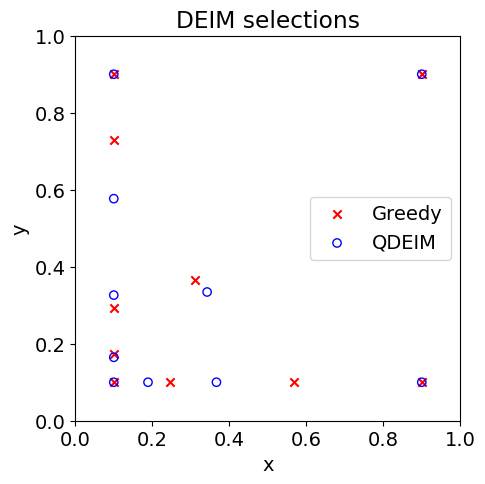

In [ ]:
"""
def plot_deim_points(indices, title):
    rows, cols = get_2d_indices(indices)

    plt.figure(figsize=(6, 5))
    plt.scatter(x[cols], y[rows], c='r', marker='x')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xlim(x[0], x[-1])
    plt.ylim(y[0], y[-1])
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()"""

# Plot both DEIM selections on the same axis
rows_g, cols_g = get_2d_indices(greedy_indices)
rows_q, cols_q = get_2d_indices(qdeim_indices_vals)

plt.figure(figsize=(6, 5))
plt.scatter(x[cols_g], y[rows_g], c="r", marker="x", label="Greedy")
plt.scatter(
    x[cols_q], y[rows_q], facecolors="none", edgecolors="b", marker="o", label="QDEIM"
)  # circle marker for QDEIM
plt.title("DEIM selections")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.show()

In [ ]:
def run_deim(U_deim, indices, mu_test, method="numerical", deim_func=None):
    EU = U_deim[indices, :]
    EU_inv = np.linalg.inv(EU)

    start = time.time()
    if method == "numerical":
        f_test_indices = f(mu_test, indices)
    elif method == "symbolic":
        f_test_indices = deim_func(*mu_test)
    else:
        raise ValueError(f"Unknown method {method}")

    c = EU_inv @ f_test_indices
    f_deim = U_deim @ c
    end = time.time()

    return f_deim, end - start


# Test input
mu_test_vals = np.random.uniform(-1, -0.01, size=(num_runs, 2))


# Run and average timings
def average_run(name, U_deim, indices, mu_tests, method, deim_func=None):
    times = []
    errors = []
    for mu in mu_tests:
        f_deim, t = run_deim(U_deim, indices, mu, method, deim_func)
        f_true = f(mu)
        err = np.linalg.norm(f_true - f_deim) / np.linalg.norm(f_true)
        times.append(t)
        errors.append(err)
    return np.mean(errors), np.std(errors), np.mean(times), np.std(times)


results = {}
for name, idx, deim_func in [
    ("Greedy", greedy_indices, greedy_deim_func),
    ("QDEIM", qdeim_indices_vals, qdeim_deim_func),
]:
    for method in ["symbolic", "numerical"]:
        err_mean, err_std, t_mean, t_std = average_run(
            name, U_deim, idx, mu_test_vals, method, deim_func
        )
        results[(name, method)] = (err_mean, err_std, t_mean, t_std)


# Modify print_results() function to output LaTeX-friendly table:
def print_results():
    # LaTeX-friendly table
    print("\\begin{tabular}{lllr}")
    print("\\hline")
    print(
        "Method & Selector & Rel. Error (mean$\\pm$std) & Time (ms, mean$\\pm$std)\\\\"
    )
    print("\\hline")
    for selector in ["Greedy", "QDEIM"]:
        for method in ["symbolic", "numerical"]:
            err_mean, err_std, t_mean, t_std = results[(selector, method)]
            print(
                f"{'A' if method == 'symbolic' else 'B'} & {selector} & {err_mean:.2e} $\\pm$ {err_std:.1e} & {t_mean*1e3:.2f} $\\pm$ {t_std*1e3:.2f}\\\\"
            )
    print("\\hline")
    print("\\end{tabular}")
    print()
    # Context lines
    print(f"All times are averages over {len(mu_test_vals)} runs.")


if __name__ == "__main__":
    print_results()

\begin{tabular}{lllr}
\hline
Method & Selector & Rel. Error (mean$\pm$std) & Time (ms, mean$\pm$std)\\
\hline
A & Greedy & 1.01e-04 $\pm$ 4.2e-05 & 0.15 $\pm$ 0.14\\
B & Greedy & 1.01e-04 $\pm$ 4.2e-05 & 0.13 $\pm$ 0.10\\
A & QDEIM & 1.11e-04 $\pm$ 4.6e-05 & 0.14 $\pm$ 0.14\\
B & QDEIM & 1.11e-04 $\pm$ 4.6e-05 & 0.08 $\pm$ 0.06\\
\hline
\end{tabular}

All times are averages over 225 runs.


<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
<>:60: SyntaxWarning: invalid escape sequence '\m'
<>:61: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\m'
<ipython-input-6-2c059f03d6b2>:60: SyntaxWarning: invalid escape sequence '\m'
  plot_comparison(f_sample, f_deim_greedy_num, f'Greedy (Numerical) ($\mu$={mu_plot})')
<ipython-input-6-2c059f03d6b2>:61: SyntaxWarning: invalid escape sequence '\m'
  plot_comparison(f_sample, f_deim_qdeim_num, f'QDEIM (Numerical) ($\mu$={mu_plot})')
<ipython-input-6-2c059f03d6b2>:62: SyntaxWarning: invalid escape sequence '\m'
  plot_comparison(f_sample, f_deim_greedy_sym, f'Greedy ($\mu$={mu_plot})')
<ipython-input-6-2c059f03d6b2>:63: SyntaxWarning: invalid escape sequence '\m'
  plot_comparison(f_sample

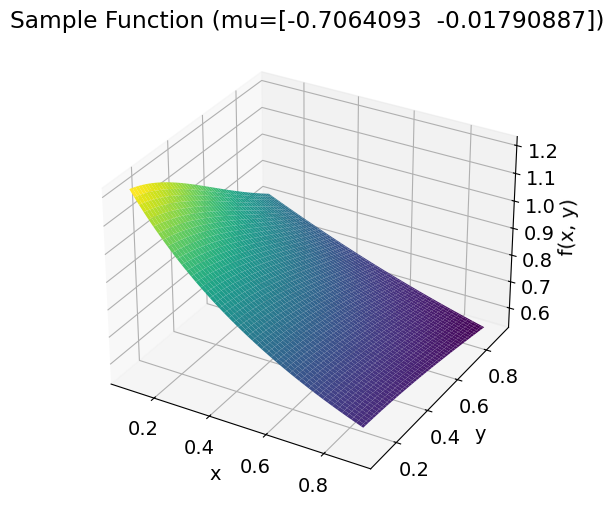

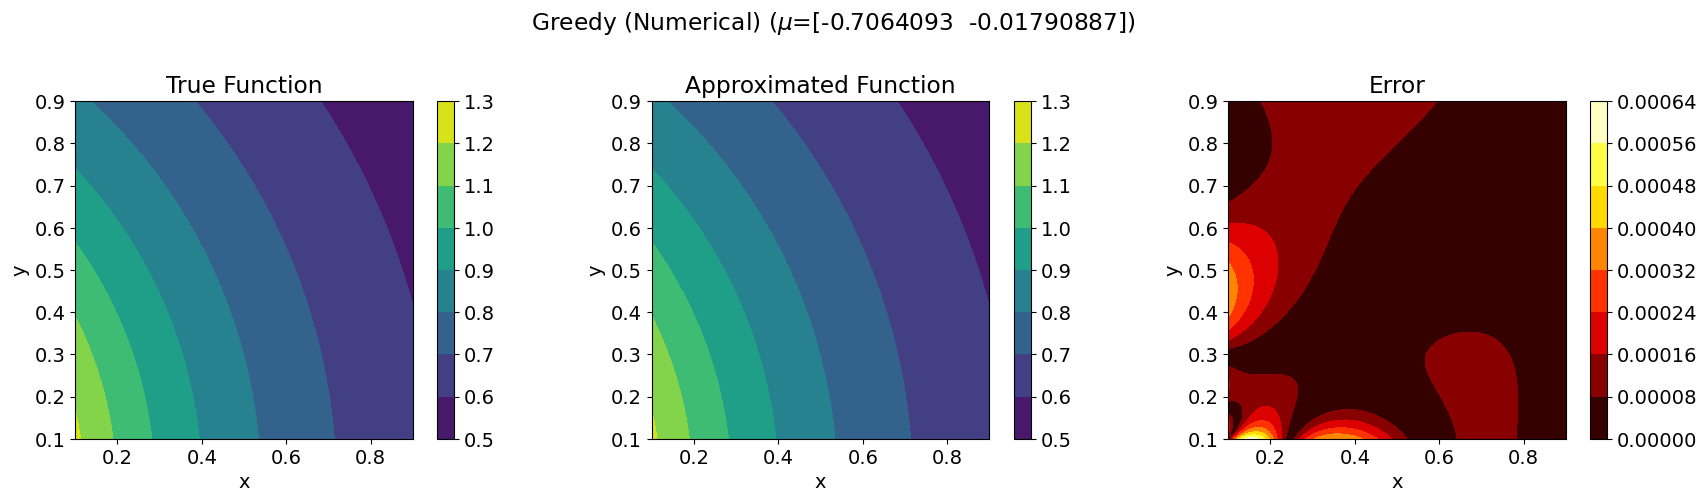

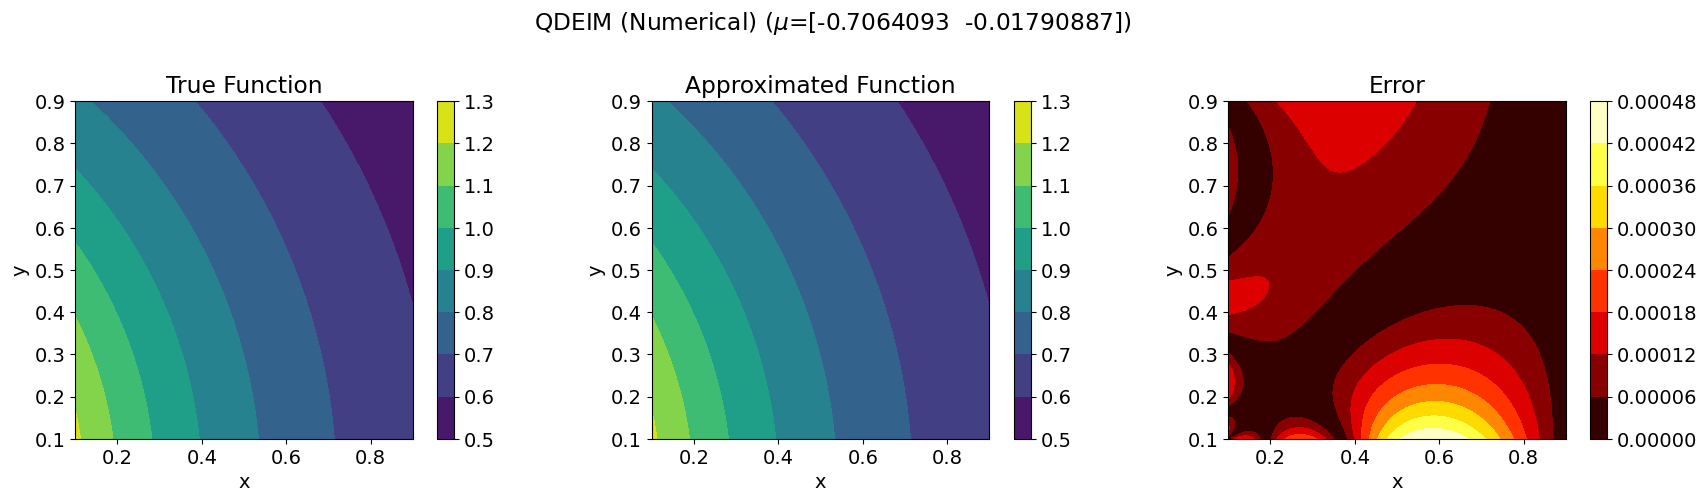

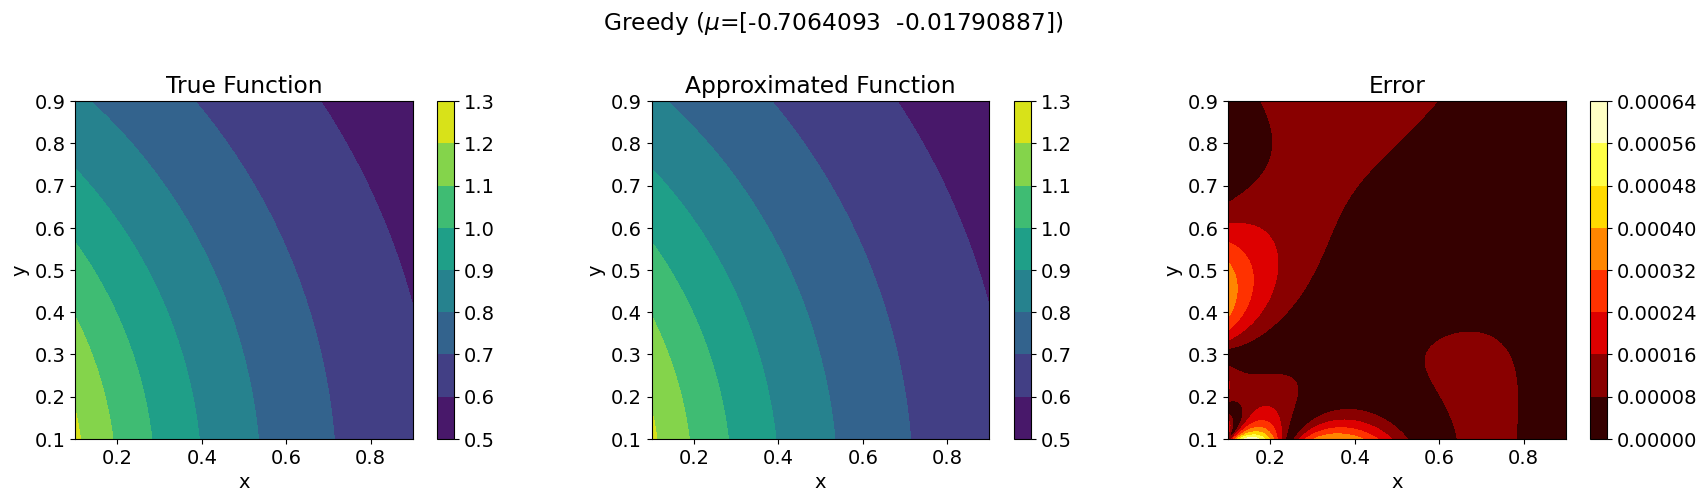

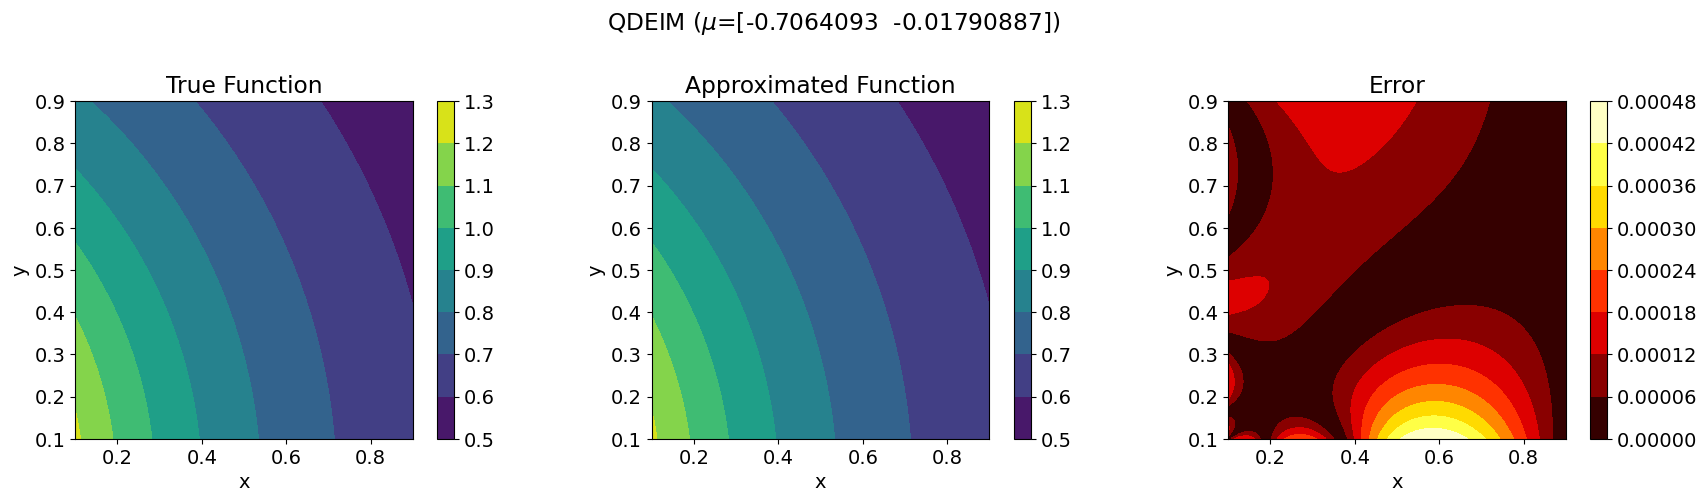

In [ ]:
mu_plot = np.random.uniform(-1, -0.01, size=(2,))
f_sample = f(mu_plot)

# Surface plot sample function
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xx, yy, f_sample.reshape((nx, ny)), cmap="viridis")
ax.set_title(f"Sample Function (mu={mu_plot})")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
plt.show()

# Get approximations for plotting
f_deim_greedy_num, _ = run_deim(U_deim, greedy_indices, mu_plot, method="numerical")
f_deim_qdeim_num, _ = run_deim(U_deim, qdeim_indices_vals, mu_plot, method="numerical")
f_deim_greedy_sym, _ = run_deim(
    U_deim, greedy_indices, mu_plot, method="symbolic", deim_func=greedy_deim_func
)
f_deim_qdeim_sym, _ = run_deim(
    U_deim, qdeim_indices_vals, mu_plot, method="symbolic", deim_func=qdeim_deim_func
)


def plot_comparison(f_true_flat, f_approx_flat, title):
    f_true = f_true_flat.reshape((nx, ny))
    f_approx = f_approx_flat.reshape((nx, ny))

    error = np.abs(f_true - f_approx)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={"aspect": "equal"})

    # True function
    im1 = axes[0].contourf(xx, yy, f_true, cmap="viridis")
    axes[0].set_title("True Function")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_xlim(xx.min(), xx.max())
    axes[0].set_ylim(yy.min(), yy.max())
    fig.colorbar(im1, ax=axes[0])

    # Approximated function
    im2 = axes[1].contourf(xx, yy, f_approx, cmap="viridis")
    axes[1].set_title("Approximated Function")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].set_xlim(xx.min(), xx.max())
    axes[1].set_ylim(yy.min(), yy.max())
    fig.colorbar(im2, ax=axes[1])

    # Error
    im3 = axes[2].contourf(xx, yy, error, cmap="hot")
    axes[2].set_title("Error")
    axes[2].set_xlabel("x")
    axes[2].set_ylabel("y")
    axes[2].set_xlim(xx.min(), xx.max())
    axes[2].set_ylim(yy.min(), yy.max())
    fig.colorbar(im3, ax=axes[2])

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


plot_comparison(f_sample, f_deim_greedy_num, f"Greedy (Numerical) ($\mu$={mu_plot})")
plot_comparison(f_sample, f_deim_qdeim_num, f"QDEIM (Numerical) ($\mu$={mu_plot})")
plot_comparison(f_sample, f_deim_greedy_sym, f"Greedy ($\mu$={mu_plot})")
plot_comparison(f_sample, f_deim_qdeim_sym, f"QDEIM ($\mu$={mu_plot})")